# Kode Python Minggu 3 — ETL dan Data Warehouse

**Proyek:** Smart Economy Kabupaten/Kota Jawa Barat  
**Kelompok:** Kelompok 3 — D4 SIKC 3B  

Notebook ini mereplikasi proses **Minggu 3**: membaca dataset inti, audit awal, preprocessing/ETL, pembuatan dimension table, fact table, data mart, data dictionary, data siap analisis 2024, serta visualisasi pendukung ETL dan star schema.


In [1]:
# ============================================================
# 0. Import library dan konfigurasi path
# ============================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

BASE_DIR = Path.cwd()

# Notebook dibuat agar fleksibel: bisa dijalankan dari folder package,
# dari /mnt/data, atau dari struktur folder hasil ekstraksi zip.
input_candidates = [
    BASE_DIR / 'jabar_week1_dataset_inti_27kabkota.csv',
    BASE_DIR.parent / 'jabar_week1_dataset_inti_27kabkota.csv',
    BASE_DIR / 'data' / 'jabar_week1_dataset_inti_27kabkota.csv',
    Path('/mnt/data/jabar_week1_dataset_inti_27kabkota.csv'),
]

INPUT_PATH = next((p for p in input_candidates if p.exists()), None)
if INPUT_PATH is None:
    raise FileNotFoundError('File jabar_week1_dataset_inti_27kabkota.csv tidak ditemukan. Letakkan file CSV satu folder dengan notebook ini.')

OUTPUT_DIR = BASE_DIR / 'data_siap_dw'
FIG_DIR = BASE_DIR / 'figures_week3'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Input dataset :', INPUT_PATH)
print('Output data   :', OUTPUT_DIR)
print('Output gambar :', FIG_DIR)

Input dataset : /mnt/data/jabar_week1_dataset_inti_27kabkota.csv
Output data   : /mnt/data/data_siap_dw
Output gambar : /mnt/data/figures_week3


## 1. Extract — Load Dataset Inti
Dataset input adalah `jabar_week1_dataset_inti_27kabkota.csv` dengan grain awal **1 baris = 1 wilayah × 1 tahun × 1 bulan**.

In [2]:
# ============================================================
# 1. EXTRACT
# ============================================================
df_raw = pd.read_csv(INPUT_PATH)

print('Shape dataset mentah:', df_raw.shape)
display(df_raw.head())

audit_awal = pd.DataFrame({
    'kolom': df_raw.columns,
    'tipe_data_awal': [str(df_raw[c].dtype) for c in df_raw.columns],
    'jumlah_non_null': [df_raw[c].notna().sum() for c in df_raw.columns],
    'jumlah_missing': [df_raw[c].isna().sum() for c in df_raw.columns],
    'persentase_missing': [round(df_raw[c].isna().mean() * 100, 2) for c in df_raw.columns],
})

display(audit_awal)

Shape dataset mentah: (1620, 18)


,wilayah,jenis_wilayah,tahun,bulan,bulan_ke,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,inflasi_yoy,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index,is_bulan_awal_tahun,is_bulan_tengah_tahun,is_bulan_akhir_tahun
0,Kabupaten Bandung,Kabupaten,2021,Januari,1,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
1,Kabupaten Bandung,Kabupaten,2021,Februari,2,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
2,Kabupaten Bandung,Kabupaten,2021,Maret,3,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
3,Kabupaten Bandung,Kabupaten,2021,April,4,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,0,1,0
4,Kabupaten Bandung,Kabupaten,2021,Mei,5,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,0,1,0


,kolom,tipe_data_awal,jumlah_non_null,jumlah_missing,persentase_missing
0,wilayah,object,1620,0,0.00
1,jenis_wilayah,object,1620,0,0.00
2,tahun,int64,1620,0,0.00
3,bulan,object,1620,0,0.00
4,bulan_ke,int64,1620,0,0.00
5,tpt,float64,1296,324,20.00
6,persentase_penduduk_miskin,float64,1620,0,0.00
7,gini_ratio,float64,1620,0,0.00
8,ipg,float64,1620,0,0.00
9,rls,float64,1620,0,0.00


## 2. Transform — Cleaning, Validasi, dan Pemisahan Grain
Transformasi utama:
- validasi kolom wajib,
- standardisasi teks wilayah dan bulan,
- konversi tipe data numerik,
- pemisahan indikator tahunan dan indikator bulanan,
- pemberian status untuk nilai yang belum tersedia agar tidak diimputasi sembarang.

In [3]:
# ============================================================
# 2. TRANSFORM - validasi kolom dan cleaning tipe data
# ============================================================
required_columns = [
    'wilayah', 'jenis_wilayah', 'tahun', 'bulan', 'bulan_ke',
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'inflasi_yoy', 'pendidikan_indeks_sederhana',
    'kemiskinan_pengangguran_index', 'gender_pendidikan_index',
    'is_bulan_awal_tahun', 'is_bulan_tengah_tahun', 'is_bulan_akhir_tahun'
]

missing_required = [c for c in required_columns if c not in df_raw.columns]
if missing_required:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_required}')

df = df_raw.copy()

# Standardisasi teks
for col in ['wilayah', 'jenis_wilayah', 'bulan']:
    df[col] = df[col].astype(str).str.strip()

# Konversi numerik
numeric_cols = [
    'tahun', 'bulan_ke', 'tpt', 'persentase_penduduk_miskin', 'gini_ratio',
    'ipg', 'rls', 'hls', 'inflasi_yoy', 'pendidikan_indeks_sederhana',
    'kemiskinan_pengangguran_index', 'gender_pendidikan_index',
    'is_bulan_awal_tahun', 'is_bulan_tengah_tahun', 'is_bulan_akhir_tahun'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Validasi cakupan wilayah
wilayah_unik = df['wilayah'].nunique()
tahun_unik = sorted(df['tahun'].dropna().astype(int).unique().tolist())
bulan_unik = df['bulan_ke'].nunique()

print('Jumlah wilayah unik:', wilayah_unik)
print('Periode tahun      :', tahun_unik)
print('Jumlah bulan       :', bulan_unik)
print('Shape setelah transform tipe data:', df.shape)

display(df.head())

Jumlah wilayah unik: 27
Periode tahun      : [2021, 2022, 2023, 2024, 2025]
Jumlah bulan       : 12
Shape setelah transform tipe data: (1620, 18)


,wilayah,jenis_wilayah,tahun,bulan,bulan_ke,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,inflasi_yoy,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index,is_bulan_awal_tahun,is_bulan_tengah_tahun,is_bulan_akhir_tahun
0,Kabupaten Bandung,Kabupaten,2021,Januari,1,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
1,Kabupaten Bandung,Kabupaten,2021,Februari,2,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
2,Kabupaten Bandung,Kabupaten,2021,Maret,3,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,1,0,0
3,Kabupaten Bandung,Kabupaten,2021,April,4,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,0,1,0
4,Kabupaten Bandung,Kabupaten,2021,Mei,5,8.32,7.15,0.386,94.59,9.07,12.7,NaN,10.885,15.47,52.7375,0,1,0


## 3. Dimension Table
Dimension table disusun untuk mendukung skema warehouse berbasis **star schema multi-fact**:
- `dim_lokasi`
- `dim_waktu_tahunan`
- `dim_waktu_bulanan`
- `dim_dashboard_stakeholder`

In [4]:
# ============================================================
# 3. DIMENSION TABLE
# ============================================================
# dim_lokasi
unique_lokasi = (
    df[['wilayah', 'jenis_wilayah']]
    .drop_duplicates()
    .sort_values('wilayah')
    .reset_index(drop=True)
)
unique_lokasi['key_lokasi'] = ['L' + str(i).zfill(3) for i in range(1, len(unique_lokasi) + 1)]
unique_lokasi['level_wilayah'] = 'Kabupaten/Kota'
dim_lokasi = unique_lokasi[['key_lokasi', 'wilayah', 'jenis_wilayah', 'level_wilayah']].rename(columns={'wilayah': 'nama_wilayah'})

# dim_waktu_tahunan
dim_waktu_tahunan = (
    df[['tahun']]
    .drop_duplicates()
    .dropna()
    .sort_values('tahun')
    .reset_index(drop=True)
)
dim_waktu_tahunan['tahun'] = dim_waktu_tahunan['tahun'].astype(int)
dim_waktu_tahunan['key_waktu_tahun'] = 'Y' + dim_waktu_tahunan['tahun'].astype(str)
dim_waktu_tahunan['periode_label'] = dim_waktu_tahunan['tahun'].astype(str)
dim_waktu_tahunan = dim_waktu_tahunan[['key_waktu_tahun', 'tahun', 'periode_label']]

# dim_waktu_bulanan
dim_waktu_bulanan = (
    df[['tahun', 'bulan', 'bulan_ke', 'is_bulan_awal_tahun', 'is_bulan_tengah_tahun', 'is_bulan_akhir_tahun']]
    .drop_duplicates()
    .dropna(subset=['tahun', 'bulan_ke'])
    .sort_values(['tahun', 'bulan_ke'])
    .reset_index(drop=True)
)
dim_waktu_bulanan['tahun'] = dim_waktu_bulanan['tahun'].astype(int)
dim_waktu_bulanan['bulan_ke'] = dim_waktu_bulanan['bulan_ke'].astype(int)
dim_waktu_bulanan['key_waktu_bulan'] = (
    'M' + dim_waktu_bulanan['tahun'].astype(str) + dim_waktu_bulanan['bulan_ke'].astype(str).str.zfill(2)
)
dim_waktu_bulanan['periode_label'] = dim_waktu_bulanan['bulan'] + ' ' + dim_waktu_bulanan['tahun'].astype(str)
dim_waktu_bulanan = dim_waktu_bulanan[[
    'key_waktu_bulan', 'tahun', 'bulan', 'bulan_ke', 'periode_label',
    'is_bulan_awal_tahun', 'is_bulan_tengah_tahun', 'is_bulan_akhir_tahun'
]]

# dim_dashboard_stakeholder
dim_dashboard_stakeholder = pd.DataFrame([
    ['D001', 'Strategic Dashboard', 'Gubernur/Pimpinan Pemprov Jabar; Bappeda Jawa Barat', 'Strategic', 'KPI utama, ranking wilayah, tren tahunan, peta prioritas', 'Kebijakan dan prioritas intervensi antarwilayah'],
    ['D002', 'Tactical Dashboard', 'Disnakertrans; Dinas Sosial; OPD ekonomi dan sosial', 'Tactical', 'Drill-down per indikator, top-bottom daerah, perubahan tahunan', 'Monitoring program dan alokasi intervensi'],
    ['D003', 'Managerial Dashboard', 'Pemerintah Kabupaten/Kota; Kepala bidang/manajer program', 'Managerial', 'Profil wilayah, gap indikator, evaluasi capaian per tahun', 'Tindak lanjut lokal dan evaluasi kinerja daerah'],
    ['D004', 'Operational Dashboard', 'Operator/Admin Data', 'Operational', 'Kelengkapan data, status missing value, konsistensi update', 'Menjaga kualitas dan kesiapan data'],
    ['D005', 'Analytical Dashboard', 'Tim BI/Data Analyst', 'Analytical', 'Korelasi, clustering, anomaly, ranking prioritas', 'Pendalaman analisis dan model lanjutan'],
    ['D006', 'Public Dashboard', 'Publik, akademisi, media', 'Public', 'Tren ringkas, profil wilayah, transparansi indikator', 'Komunikasi dan akuntabilitas publik'],
], columns=['key_dashboard', 'jenis_dashboard', 'pengguna_utama', 'level_keputusan', 'kebutuhan_informasi', 'keputusan_yang_didukung'])

print('dim_lokasi:', dim_lokasi.shape)
print('dim_waktu_tahunan:', dim_waktu_tahunan.shape)
print('dim_waktu_bulanan:', dim_waktu_bulanan.shape)
print('dim_dashboard_stakeholder:', dim_dashboard_stakeholder.shape)
display(dim_lokasi.head())
display(dim_waktu_tahunan)
display(dim_waktu_bulanan.head())

dim_lokasi: (27, 4)
dim_waktu_tahunan: (5, 3)
dim_waktu_bulanan: (60, 8)
dim_dashboard_stakeholder: (6, 6)


,key_lokasi,nama_wilayah,jenis_wilayah,level_wilayah
0,L001,Kabupaten Bandung,Kabupaten,Kabupaten/Kota
1,L002,Kabupaten Bandung Barat,Kabupaten,Kabupaten/Kota
2,L003,Kabupaten Bekasi,Kabupaten,Kabupaten/Kota
3,L004,Kabupaten Bogor,Kabupaten,Kabupaten/Kota
4,L005,Kabupaten Ciamis,Kabupaten,Kabupaten/Kota


,key_waktu_tahun,tahun,periode_label
0,Y2021,2021,2021
1,Y2022,2022,2022
2,Y2023,2023,2023
3,Y2024,2024,2024
4,Y2025,2025,2025


,key_waktu_bulan,tahun,bulan,bulan_ke,periode_label,is_bulan_awal_tahun,is_bulan_tengah_tahun,is_bulan_akhir_tahun
0,M202101,2021,Januari,1,Januari 2021,1,0,0
1,M202102,2021,Februari,2,Februari 2021,1,0,0
2,M202103,2021,Maret,3,Maret 2021,1,0,0
3,M202104,2021,April,4,April 2021,0,1,0
4,M202105,2021,Mei,5,Mei 2021,0,1,0


## 4. Fact Table
Fact table dipisahkan berdasarkan grain:
- `fact_kinerja_ekonomi_tahunan`: 1 baris = 1 wilayah × 1 tahun.
- `fact_inflasi_bulanan`: 1 baris = 1 wilayah × 1 tahun × 1 bulan.

Pemisahan ini mencegah salah agregasi antara indikator tahunan dan indikator bulanan.

In [5]:
# ============================================================
# 4. FACT TABLE
# ============================================================
# Mapping key
map_lokasi = dim_lokasi[['key_lokasi', 'nama_wilayah']].rename(columns={'nama_wilayah': 'wilayah'})
map_tahun = dim_waktu_tahunan[['key_waktu_tahun', 'tahun']]
map_bulan = dim_waktu_bulanan[['key_waktu_bulan', 'tahun', 'bulan_ke']]

# Fact tahunan: indikator tahunan direduksi dari data panel bulanan
annual_cols = [
    'wilayah', 'tahun', 'tpt', 'persentase_penduduk_miskin', 'gini_ratio',
    'ipg', 'rls', 'hls', 'pendidikan_indeks_sederhana',
    'kemiskinan_pengangguran_index', 'gender_pendidikan_index'
]

fact_kinerja = (
    df[annual_cols]
    .sort_values(['wilayah', 'tahun'])
    .groupby(['wilayah', 'tahun'], as_index=False)
    .first()
)
fact_kinerja = fact_kinerja.merge(map_lokasi, on='wilayah', how='left')
fact_kinerja = fact_kinerja.merge(map_tahun, on='tahun', how='left')
fact_kinerja = fact_kinerja.sort_values(['key_lokasi', 'tahun']).reset_index(drop=True)
fact_kinerja['id_fact_kinerja'] = ['FK' + str(i).zfill(4) for i in range(1, len(fact_kinerja) + 1)]
fact_kinerja['status_tpt'] = np.where(fact_kinerja['tpt'].notna(), 'tersedia', 'belum_tersedia')
fact_kinerja['status_indeks_kerentanan'] = np.where(fact_kinerja['kemiskinan_pengangguran_index'].notna(), 'tersedia', 'belum_tersedia')
fact_kinerja['keterangan_etl'] = np.where(
    fact_kinerja[['tpt', 'kemiskinan_pengangguran_index']].isna().any(axis=1),
    'Terdapat indikator tahunan yang belum tersedia; tidak diimputasi',
    'OK'
)

fact_kinerja_ekonomi_tahunan = fact_kinerja[[
    'id_fact_kinerja', 'key_lokasi', 'key_waktu_tahun',
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index', 'gender_pendidikan_index',
    'status_tpt', 'status_indeks_kerentanan', 'keterangan_etl'
]]

# Fact inflasi bulanan: indikator bulanan tetap mengikuti grain wilayah x tahun x bulan
fact_inflasi = df[['wilayah', 'tahun', 'bulan_ke', 'inflasi_yoy']].copy()
fact_inflasi = fact_inflasi.merge(map_lokasi, on='wilayah', how='left')
fact_inflasi = fact_inflasi.merge(map_bulan, on=['tahun', 'bulan_ke'], how='left')
fact_inflasi = fact_inflasi.sort_values(['key_lokasi', 'tahun', 'bulan_ke']).reset_index(drop=True)
fact_inflasi['id_fact_inflasi'] = ['FI' + str(i).zfill(5) for i in range(1, len(fact_inflasi) + 1)]
fact_inflasi['status_inflasi'] = np.where(fact_inflasi['inflasi_yoy'].notna(), 'tersedia', 'belum_tersedia')
fact_inflasi['keterangan_etl'] = np.where(
    fact_inflasi['inflasi_yoy'].notna(),
    'OK',
    'Inflasi belum tersedia pada kombinasi wilayah-bulan; tidak diimputasi'
)

fact_inflasi_bulanan = fact_inflasi[[
    'id_fact_inflasi', 'key_lokasi', 'key_waktu_bulan', 'inflasi_yoy', 'status_inflasi', 'keterangan_etl'
]]

print('fact_kinerja_ekonomi_tahunan:', fact_kinerja_ekonomi_tahunan.shape)
print('fact_inflasi_bulanan:', fact_inflasi_bulanan.shape)
display(fact_kinerja_ekonomi_tahunan.head())
display(fact_inflasi_bulanan.head())

fact_kinerja_ekonomi_tahunan: (135, 15)
fact_inflasi_bulanan: (1620, 6)


,id_fact_kinerja,key_lokasi,key_waktu_tahun,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index,status_tpt,status_indeks_kerentanan,keterangan_etl
0,FK0001,L001,Y2021,8.32,7.15,0.386,94.59,9.07,12.70,10.885,15.47,52.7375,tersedia,tersedia,OK
1,FK0002,L001,Y2022,6.98,6.80,0.370,94.71,9.08,12.71,10.895,13.78,52.8025,tersedia,tersedia,OK
2,FK0003,L001,Y2023,6.52,6.40,0.348,94.80,9.10,12.73,10.915,12.92,52.8575,tersedia,tersedia,OK
3,FK0004,L001,Y2024,6.36,6.19,0.364,95.10,9.15,12.74,10.945,12.55,53.0225,tersedia,tersedia,OK
4,FK0005,L001,Y2025,NaN,6.04,0.385,95.26,9.40,12.99,11.195,NaN,53.2275,belum_tersedia,belum_tersedia,Terdapat indikator tahunan yang belum tersedia...


,id_fact_inflasi,key_lokasi,key_waktu_bulan,inflasi_yoy,status_inflasi,keterangan_etl
0,FI00001,L001,M202101,NaN,belum_tersedia,Inflasi belum tersedia pada kombinasi wilayah-...
1,FI00002,L001,M202102,NaN,belum_tersedia,Inflasi belum tersedia pada kombinasi wilayah-...
2,FI00003,L001,M202103,NaN,belum_tersedia,Inflasi belum tersedia pada kombinasi wilayah-...
3,FI00004,L001,M202104,NaN,belum_tersedia,Inflasi belum tersedia pada kombinasi wilayah-...
4,FI00005,L001,M202105,NaN,belum_tersedia,Inflasi belum tersedia pada kombinasi wilayah-...


## 5. Data Mart dan Data Ready Analisis 2024
Data mart dibuat dengan menggabungkan fact dan dimension agar siap dipakai di dashboard dan analisis. Dataset `data_ready_analisis_2024.csv` disiapkan sebagai input Data Mining Minggu 4.

In [6]:
# ============================================================
# 5. DATA MART DAN DATA READY ANALISIS 2024
# ============================================================
mart_kinerja_ekonomi_tahunan = (
    fact_kinerja_ekonomi_tahunan
    .merge(dim_lokasi, on='key_lokasi', how='left')
    .merge(dim_waktu_tahunan, on='key_waktu_tahun', how='left')
)
mart_kinerja_ekonomi_tahunan = mart_kinerja_ekonomi_tahunan[[
    'id_fact_kinerja', 'nama_wilayah', 'jenis_wilayah', 'tahun',
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index', 'gender_pendidikan_index',
    'status_tpt', 'status_indeks_kerentanan', 'keterangan_etl'
]]

mart_inflasi_bulanan = (
    fact_inflasi_bulanan
    .merge(dim_lokasi, on='key_lokasi', how='left')
    .merge(dim_waktu_bulanan, on='key_waktu_bulan', how='left')
)
mart_inflasi_bulanan = mart_inflasi_bulanan[[
    'id_fact_inflasi', 'nama_wilayah', 'jenis_wilayah', 'tahun', 'bulan', 'bulan_ke', 'periode_label',
    'inflasi_yoy', 'status_inflasi', 'keterangan_etl'
]]

model_features = [
    'tpt', 'persentase_penduduk_miskin', 'gini_ratio', 'ipg', 'rls', 'hls',
    'pendidikan_indeks_sederhana', 'kemiskinan_pengangguran_index', 'gender_pendidikan_index'
]
data_ready_analisis_2024 = (
    mart_kinerja_ekonomi_tahunan
    .query('tahun == 2024')
    [['nama_wilayah', 'jenis_wilayah', 'tahun'] + model_features]
    .dropna(subset=model_features)
    .sort_values('nama_wilayah')
    .reset_index(drop=True)
)

print('mart_kinerja_ekonomi_tahunan:', mart_kinerja_ekonomi_tahunan.shape)
print('mart_inflasi_bulanan:', mart_inflasi_bulanan.shape)
print('data_ready_analisis_2024:', data_ready_analisis_2024.shape)
display(data_ready_analisis_2024.head())

mart_kinerja_ekonomi_tahunan:

 (135, 16)
mart_inflasi_bulanan: (1620, 10)
data_ready_analisis_2024: (27, 12)


,nama_wilayah,jenis_wilayah,tahun,tpt,persentase_penduduk_miskin,gini_ratio,ipg,rls,hls,pendidikan_indeks_sederhana,kemiskinan_pengangguran_index,gender_pendidikan_index
0,Kabupaten Bandung,Kabupaten,2024,6.36,6.19,0.364,95.10,9.15,12.74,10.945,12.55,53.0225
1,Kabupaten Bandung Barat,Kabupaten,2024,6.70,10.49,0.400,81.59,8.24,12.00,10.120,17.19,45.8550
2,Kabupaten Bekasi,Kabupaten,2024,8.82,4.80,0.367,90.18,9.76,13.18,11.470,13.62,50.8250
3,Kabupaten Bogor,Kabupaten,2024,7.34,7.05,0.398,90.98,8.39,12.75,10.570,14.39,50.7750
4,Kabupaten Ciamis,Kabupaten,2024,3.37,7.39,0.326,88.29,8.10,14.30,11.200,10.76,49.7450


## 6. Ringkasan Objek ETL dan Data Dictionary
Bagian ini membuat dokumentasi teknis yang bisa dimasukkan ke lampiran atau dipakai sebagai penjelasan output data warehouse.

In [7]:
# ============================================================
# 6. RINGKASAN OBJEK DAN DATA DICTIONARY
# ============================================================
objects = {
    'dim_lokasi': dim_lokasi,
    'dim_waktu_tahunan': dim_waktu_tahunan,
    'dim_waktu_bulanan': dim_waktu_bulanan,
    'dim_dashboard_stakeholder': dim_dashboard_stakeholder,
    'fact_kinerja_ekonomi_tahunan': fact_kinerja_ekonomi_tahunan,
    'fact_inflasi_bulanan': fact_inflasi_bulanan,
    'mart_kinerja_ekonomi_tahunan': mart_kinerja_ekonomi_tahunan,
    'mart_inflasi_bulanan': mart_inflasi_bulanan,
    'data_ready_analisis_2024': data_ready_analisis_2024,
}

ringkasan_objek_etl_dw = pd.DataFrame([
    ['dim_lokasi', 'Dimension', len(dim_lokasi), dim_lokasi.shape[1], '1 baris = 1 wilayah kabupaten/kota'],
    ['dim_waktu_tahunan', 'Dimension', len(dim_waktu_tahunan), dim_waktu_tahunan.shape[1], '1 baris = 1 tahun'],
    ['dim_waktu_bulanan', 'Dimension', len(dim_waktu_bulanan), dim_waktu_bulanan.shape[1], '1 baris = 1 bulan dalam satu tahun'],
    ['dim_dashboard_stakeholder', 'Dimension', len(dim_dashboard_stakeholder), dim_dashboard_stakeholder.shape[1], '1 baris = 1 jenis dashboard/stakeholder'],
    ['fact_kinerja_ekonomi_tahunan', 'Fact', len(fact_kinerja_ekonomi_tahunan), fact_kinerja_ekonomi_tahunan.shape[1], '1 baris = 1 wilayah x 1 tahun'],
    ['fact_inflasi_bulanan', 'Fact', len(fact_inflasi_bulanan), fact_inflasi_bulanan.shape[1], '1 baris = 1 wilayah x 1 bulan x 1 tahun'],
    ['mart_kinerja_ekonomi_tahunan', 'Data Mart', len(mart_kinerja_ekonomi_tahunan), mart_kinerja_ekonomi_tahunan.shape[1], 'fact tahunan + dim lokasi + dim tahun'],
    ['mart_inflasi_bulanan', 'Data Mart', len(mart_inflasi_bulanan), mart_inflasi_bulanan.shape[1], 'fact inflasi + dim lokasi + dim bulan'],
    ['data_ready_analisis_2024', 'Analytical Dataset', len(data_ready_analisis_2024), data_ready_analisis_2024.shape[1], '1 baris = 1 wilayah tahun 2024'],
], columns=['nama_objek', 'jenis_objek', 'jumlah_baris', 'jumlah_kolom', 'grain'])

rows = []
for nama_objek, table in objects.items():
    for col in table.columns:
        contoh = table[col].dropna().iloc[0] if table[col].notna().any() else np.nan
        rows.append({
            'nama_objek': nama_objek,
            'kolom': col,
            'tipe_data': str(table[col].dtype),
            'jumlah_non_null': int(table[col].notna().sum()),
            'contoh_nilai': contoh,
        })

data_dictionary_etl_dw = pd.DataFrame(rows)

display(ringkasan_objek_etl_dw)
display(data_dictionary_etl_dw.head(15))

,nama_objek,jenis_objek,jumlah_baris,jumlah_kolom,grain
0,dim_lokasi,Dimension,27,4,1 baris = 1 wilayah kabupaten/kota
1,dim_waktu_tahunan,Dimension,5,3,1 baris = 1 tahun
2,dim_waktu_bulanan,Dimension,60,8,1 baris = 1 bulan dalam satu tahun
3,dim_dashboard_stakeholder,Dimension,6,6,1 baris = 1 jenis dashboard/stakeholder
4,fact_kinerja_ekonomi_tahunan,Fact,135,15,1 baris = 1 wilayah x 1 tahun
5,fact_inflasi_bulanan,Fact,1620,6,1 baris = 1 wilayah x 1 bulan x 1 tahun
6,mart_kinerja_ekonomi_tahunan,Data Mart,135,16,fact tahunan + dim lokasi + dim tahun
7,mart_inflasi_bulanan,Data Mart,1620,10,fact inflasi + dim lokasi + dim bulan
8,data_ready_analisis_2024,Analytical Dataset,27,12,1 baris = 1 wilayah tahun 2024


,nama_objek,kolom,tipe_data,jumlah_non_null,contoh_nilai
0,dim_lokasi,key_lokasi,object,27,L001
1,dim_lokasi,nama_wilayah,object,27,Kabupaten Bandung
2,dim_lokasi,jenis_wilayah,object,27,Kabupaten
3,dim_lokasi,level_wilayah,object,27,Kabupaten/Kota
4,dim_waktu_tahunan,key_waktu_tahun,object,5,Y2021
5,dim_waktu_tahunan,tahun,int64,5,2021
6,dim_waktu_tahunan,periode_label,object,5,2021
7,dim_waktu_bulanan,key_waktu_bulan,object,60,M202101
8,dim_waktu_bulanan,tahun,int64,60,2021
9,dim_waktu_bulanan,bulan,object,60,Januari


## 7. Visualisasi Pendukung ETL dan Star Schema
Visualisasi berikut bisa dipakai sebagai screenshot/potongan hasil implementasi teknis.

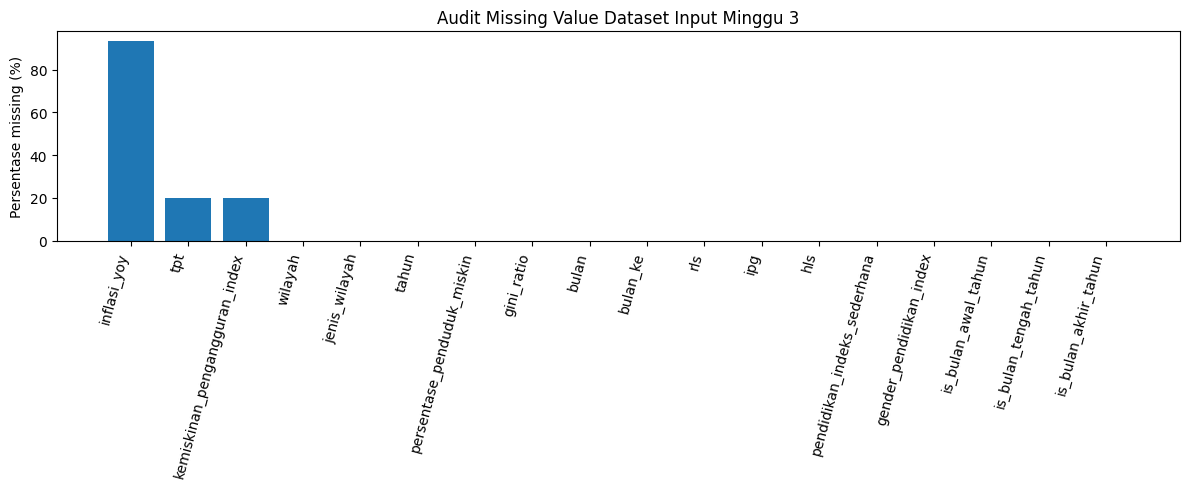

In [8]:
# ============================================================
# 7A. Visualisasi kelengkapan data per variabel
# ============================================================
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(missing_percent.index, missing_percent.values)
plt.xticks(rotation=75, ha='right')
plt.ylabel('Persentase missing (%)')
plt.title('Audit Missing Value Dataset Input Minggu 3')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_week3_audit_missing_value.png', dpi=200)
plt.show()

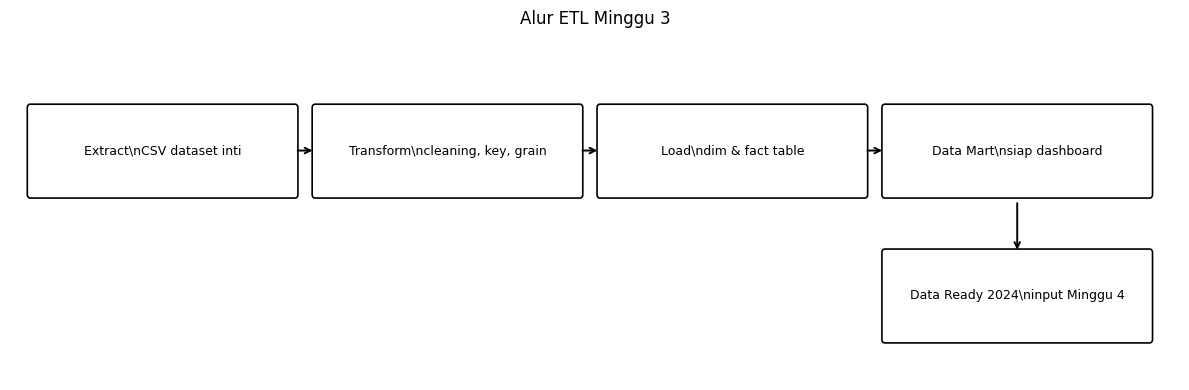

In [9]:
# ============================================================
# 7B. Diagram alur ETL sederhana
# ============================================================
def draw_box(ax, xy, text, width=2.6, height=0.75):
    x, y = xy
    box = FancyBboxPatch((x, y), width, height, boxstyle='round,pad=0.03', linewidth=1.2, facecolor='white')
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=9)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

boxes = [
    ((0.2, 1.6), 'Extract\\nCSV dataset inti'),
    ((3.0, 1.6), 'Transform\\ncleaning, key, grain'),
    ((5.8, 1.6), 'Load\\ndim & fact table'),
    ((8.6, 1.6), 'Data Mart\\nsiap dashboard'),
    ((8.6, 0.35), 'Data Ready 2024\\ninput Minggu 4'),
]
for xy, text in boxes:
    draw_box(ax, xy, text)

arrow_pairs = [((2.8, 1.98), (3.0, 1.98)), ((5.6, 1.98), (5.8, 1.98)), ((8.4, 1.98), (8.6, 1.98)), ((9.9, 1.55), (9.9, 1.1))]
for start, end in arrow_pairs:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', linewidth=1.4))

ax.set_xlim(0, 11.5)
ax.set_ylim(0, 3)
plt.title('Alur ETL Minggu 3')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_week3_alur_etl.png', dpi=200)
plt.show()

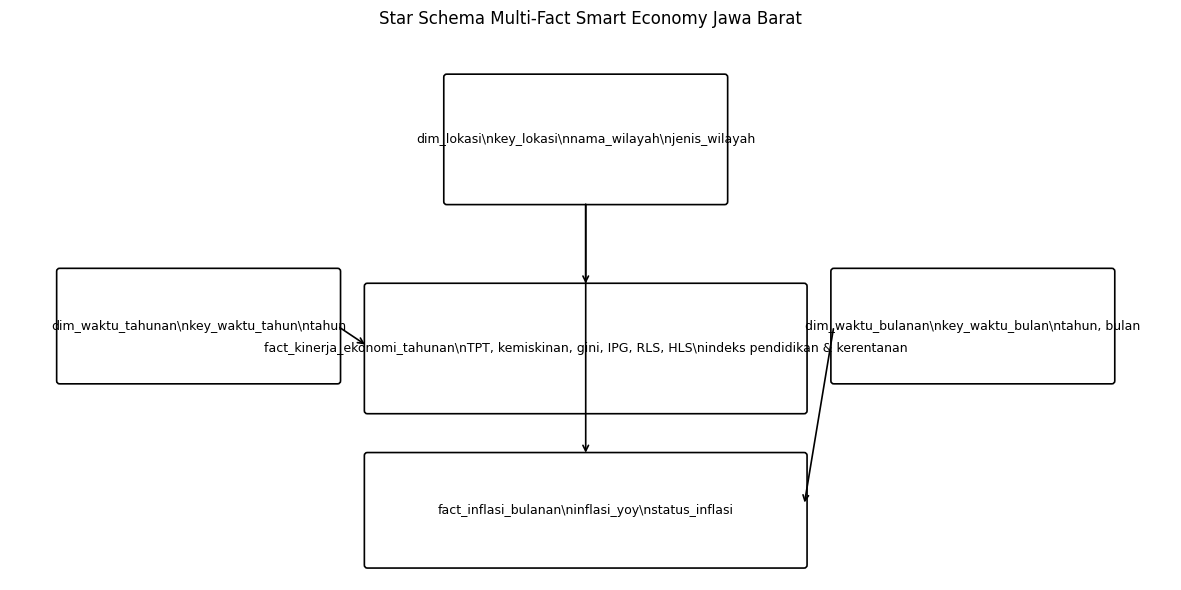

In [10]:
# ============================================================
# 7C. Diagram star schema multi-fact sederhana
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

schema_boxes = [
    ((4.4, 3.8), 'dim_lokasi\\nkey_lokasi\\nnama_wilayah\\njenis_wilayah', 2.8, 1.25),
    ((0.5, 2.0), 'dim_waktu_tahunan\\nkey_waktu_tahun\\ntahun', 2.8, 1.1),
    ((8.3, 2.0), 'dim_waktu_bulanan\\nkey_waktu_bulan\\ntahun, bulan', 2.8, 1.1),
    ((3.6, 1.7), 'fact_kinerja_ekonomi_tahunan\\nTPT, kemiskinan, gini, IPG, RLS, HLS\\nindeks pendidikan & kerentanan', 4.4, 1.25),
    ((3.6, 0.15), 'fact_inflasi_bulanan\\ninflasi_yoy\\nstatus_inflasi', 4.4, 1.1),
]

for xy, text, w, h in schema_boxes:
    draw_box(ax, xy, text, width=w, height=h)

connections = [
    ((5.8, 3.8), (5.8, 2.95)),
    ((3.3, 2.55), (3.6, 2.35)),
    ((8.3, 2.55), (8.0, 0.75)),
    ((5.8, 3.8), (5.8, 1.25)),
]
for start, end in connections:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', linewidth=1.2))

ax.set_xlim(0, 11.7)
ax.set_ylim(0, 5.5)
plt.title('Star Schema Multi-Fact Smart Economy Jawa Barat')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_week3_star_schema.png', dpi=200)
plt.show()

## 8. Load — Simpan Output CSV
Seluruh objek hasil transformasi disimpan ke folder `data_siap_dw` agar siap dipakai untuk Minggu 4, dashboard, dan lampiran laporan.

In [11]:
# ============================================================
# 8. LOAD - simpan output CSV
# ============================================================
for nama_objek, table in objects.items():
    table.to_csv(OUTPUT_DIR / f'{nama_objek}.csv', index=False)

ringkasan_objek_etl_dw.to_csv(OUTPUT_DIR / 'ringkasan_objek_etl_dw.csv', index=False)
data_dictionary_etl_dw.to_csv(OUTPUT_DIR / 'data_dictionary_etl_dw.csv', index=False)

print('Output CSV berhasil disimpan di:', OUTPUT_DIR)
for file in sorted(OUTPUT_DIR.glob('*.csv')):
    print('-', file.name)

Output CSV berhasil disimpan di: /mnt/data/data_siap_dw
- data_dictionary_etl_dw.csv
- data_ready_analisis_2024.csv
- dim_dashboard_stakeholder.csv
- dim_lokasi.csv
- dim_waktu_bulanan.csv
- dim_waktu_tahunan.csv
- fact_inflasi_bulanan.csv
- fact_kinerja_ekonomi_tahunan.csv
- mart_inflasi_bulanan.csv
- mart_kinerja_ekonomi_tahunan.csv
- ringkasan_objek_etl_dw.csv


## 9. Validasi Akhir Minggu 3
Validasi ini memastikan output utama sesuai rancangan: dimensi, fact table, data mart, dan data siap analisis 2024 tersedia.

In [12]:
# ============================================================
# 9. VALIDASI AKHIR
# ============================================================
expected_files = [
    'dim_lokasi.csv',
    'dim_waktu_tahunan.csv',
    'dim_waktu_bulanan.csv',
    'dim_dashboard_stakeholder.csv',
    'fact_kinerja_ekonomi_tahunan.csv',
    'fact_inflasi_bulanan.csv',
    'mart_kinerja_ekonomi_tahunan.csv',
    'mart_inflasi_bulanan.csv',
    'data_ready_analisis_2024.csv',
    'ringkasan_objek_etl_dw.csv',
    'data_dictionary_etl_dw.csv',
]

validasi = pd.DataFrame({
    'file_output': expected_files,
    'tersedia': [(OUTPUT_DIR / f).exists() for f in expected_files],
    'ukuran_kb': [round((OUTPUT_DIR / f).stat().st_size / 1024, 2) if (OUTPUT_DIR / f).exists() else np.nan for f in expected_files]
})

display(validasi)
print('Jumlah baris data_ready_analisis_2024:', len(data_ready_analisis_2024))
print('Jumlah wilayah data_ready_analisis_2024:', data_ready_analisis_2024['nama_wilayah'].nunique())

,file_output,tersedia,ukuran_kb
0,dim_lokasi.csv,True,1.25
1,dim_waktu_tahunan.csv,True,0.11
2,dim_waktu_bulanan.csv,True,2.50
3,dim_dashboard_stakeholder.csv,True,1.12
4,fact_kinerja_ekonomi_tahunan.csv,True,14.26
5,fact_inflasi_bulanan.csv,True,161.95
6,mart_kinerja_ekonomi_tahunan.csv,True,16.81
7,mart_inflasi_bulanan.csv,True,223.76
8,data_ready_analisis_2024.csv,True,2.42
9,ringkasan_objek_etl_dw.csv,True,0.68


Jumlah baris data_ready_analisis_2024: 27
Jumlah wilayah data_ready_analisis_2024: 27
